
# **Car Make and Model Recognition Using EfficientNet-B0**

## **Computer Vision Systems Development – Final Project**

This project develops a deep learning-based computer vision system for fine-grained car classification. The system receives an image of a car and predicts its specific make, model, and year.

The project uses the Stanford Cars dataset and a pretrained EfficientNet-B0 convolutional neural network. Transfer learning and fine-tuning are applied to adapt the pretrained model to the car classification task.



## **1. Project Idea**

The goal of this project is to develop an automatic car make and model recognition system using deep learning.

Car models can have very similar visual characteristics, making automatic recognition a challenging fine-grained image classification problem. The proposed system uses a convolutional neural network to analyze a car image and identify its specific make, model, and year.

A pretrained EfficientNet-B0 model is fine-tuned on the Stanford Cars dataset to perform the classification task.

## **2. Problem Definition**

### **Problem**

The objective is to classify an input image of a car into its correct make, model, and year.

This is a fine-grained image classification problem because many vehicle classes have very similar visual appearances. The model therefore needs to learn subtle differences in vehicle shape, headlights, grills, body design, and other visual characteristics.

### **Purpose**

The purpose of the system is to demonstrate how deep learning and transfer learning can be applied to automatically recognize specific vehicle models from images.

Potential applications include:

- Intelligent transportation systems
- Vehicle inventory management
- Automotive image search
- Parking and vehicle monitoring systems
- Automated vehicle identification

### Expected Output
**bold text**
The system receives a car image as input and produces one of 196 car classes as its predicted output.

Each class represents a specific car make, model, and year.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from datasets import load_dataset
import torch
import torch.nn as nn
from torchvision import transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torch.utils.data import DataLoader
import torch.optim as optim

## 3. **Dataset**

The Stanford Cars dataset is used for this project.

The dataset contains images of different vehicle makes, models, and years and is designed for fine-grained image classification.

### **Dataset Characteristics**

- Number of classes: **196**
- Training images: approximately **8,144**
- Test images: approximately **8,000**
- Input: RGB car images
- Output: car make/model/year class

The original training dataset is further divided into training and validation subsets.

The final data organization is:

- **Training set:** used to update the model parameters.
- **Validation set:** used to monitor generalization performance and select the best model.
- **Test set:** kept separate and used only for final evaluation.

A stratified split is used for the training and validation sets to preserve the class distribution across the 196 classes.

In [2]:
# Install Hugging Face Datasets and supporting libraries
!pip -q install -U datasets huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 846.4/846.4 kB 54.5 MB/s eta 0:00:00


In [ ]:
# Load Stanford Cars from Hugging Face
dataset = load_dataset("Donghyun99/Stanford-Cars")
print(dataset)

## **now we explore the dataset deeply to understand it right**
## **4. Dataset Exploration**

Before training the model, the dataset is explored to understand its structure and verify that the images and labels are loaded correctly.

The exploration includes:

- Inspecting the dataset structure
- Checking the number of training and test samples
- Examining the 196 class labels
- Displaying example car images
- Examining the class distribution
- Inspecting the original image dimensions

Exploring the dataset before training is important because it helps verify the quality and structure of the data and informs the preprocessing strategy used by the model.

In [4]:
train_data = dataset["train"]
test_data = dataset["test"]

# Number of splits
print("Number of Training samples:", len(train_data))
print("Number of Testing samples :", len(test_data))

# Number of car classes
class_names = train_data.features["label"].names
print("Number of classes:", len(class_names))


Number of Training samples: 8143
Number of Testing samples : 8040
Number of classes: 196


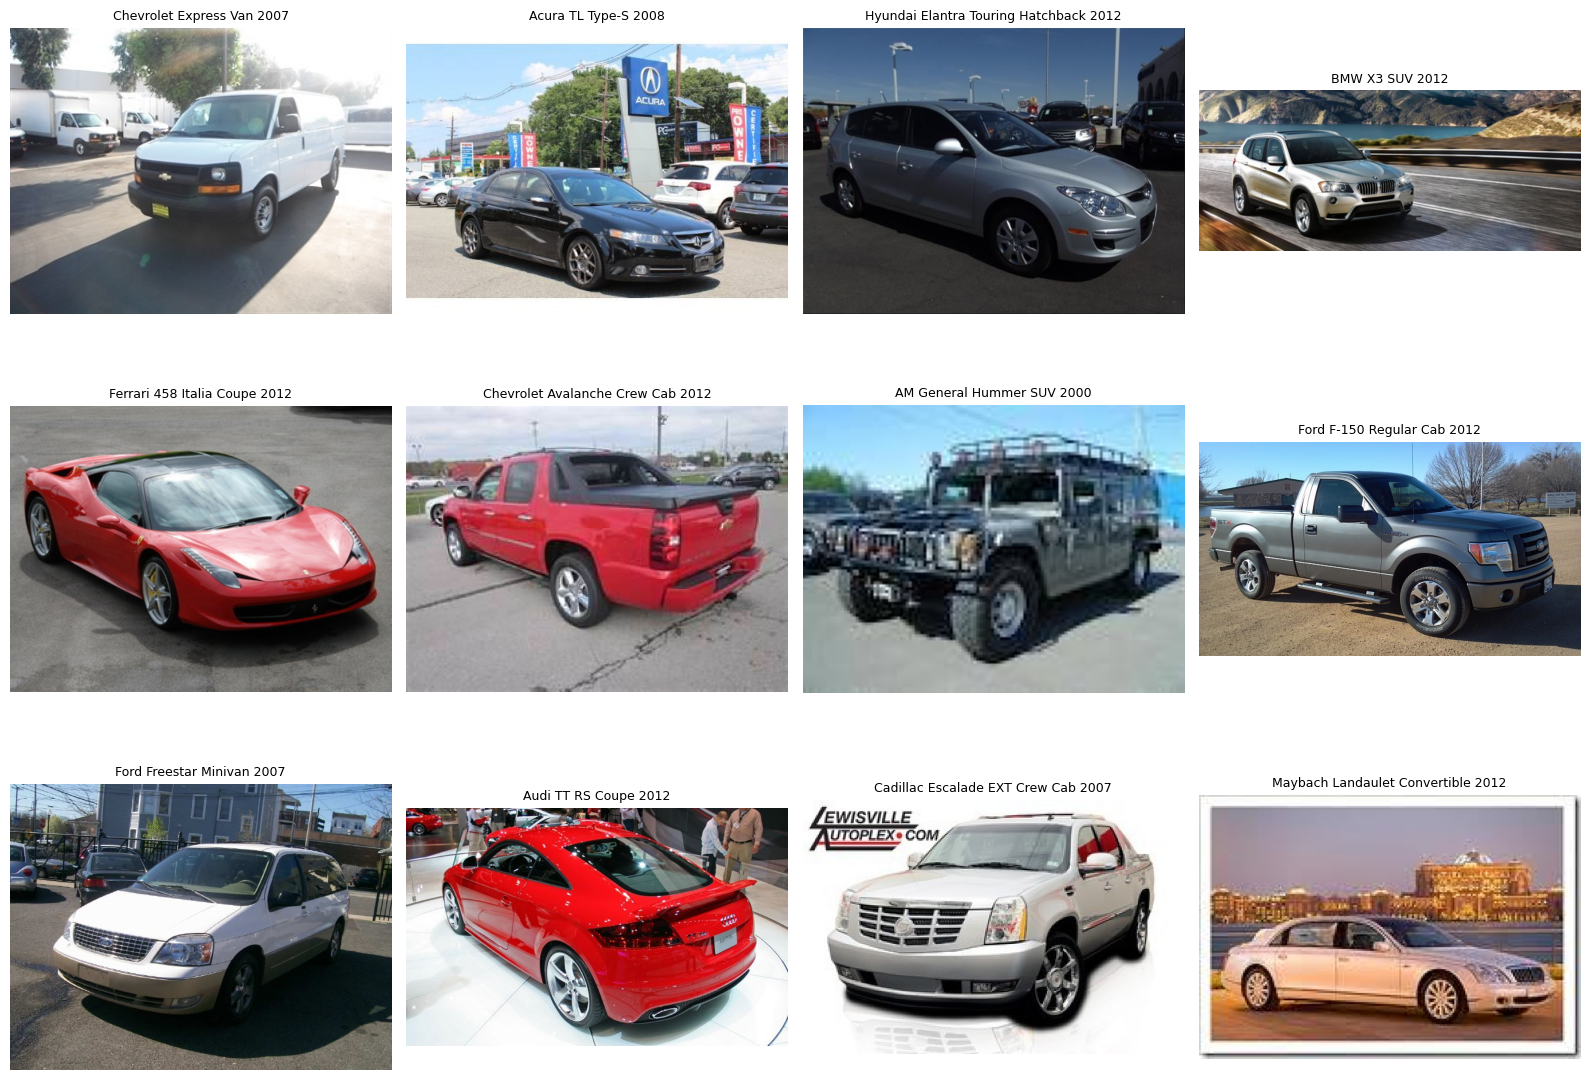

In [5]:
# Peak into training samples
num_images = 12
random_indices = np.random.choice(len(train_data), num_images, replace=False)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for ax, idx in zip(axes, random_indices):

    sample = train_data[int(idx)]

    ax.imshow(sample["image"])
    ax.axis("off")

    label_id = sample["label"]
    label_name = train_data.features["label"].names[label_id]

    ax.set_title(label_name, fontsize=9)

plt.tight_layout()
plt.show()

**checking if the dataset classes is balanced**

In [6]:
# Count training images per class

train_labels = train_data["label"]
class_counts = Counter(train_labels)
class_distribution = pd.DataFrame({
    "Class ID": list(class_counts.keys()),
    "Class Name": [class_names[i] for i in class_counts.keys()],
    "Number of Images": list(class_counts.values())
})

class_distribution = class_distribution.sort_values(
    by="Number of Images",
    ascending=False
)

class_distribution.head(20)

,Class ID,Class Name,Number of Images
38,118,GMC Savana Van 2012,68
19,78,Chrysler 300 SRT-8 2010,49
8,166,Mitsubishi Lancer Sedan 2012,48
86,160,Mercedes-Benz 300-Class Convertible 1993,48
89,143,Jaguar XK XKR 2012,47
94,55,Chevrolet Corvette ZR1 2012,47
37,190,Volkswagen Golf Hatchback 1991,46
92,170,Nissan 240SX Coupe 1998,46
69,19,Audi S6 Sedan 2011,46
65,42,Bentley Continental GT Coupe 2007,46


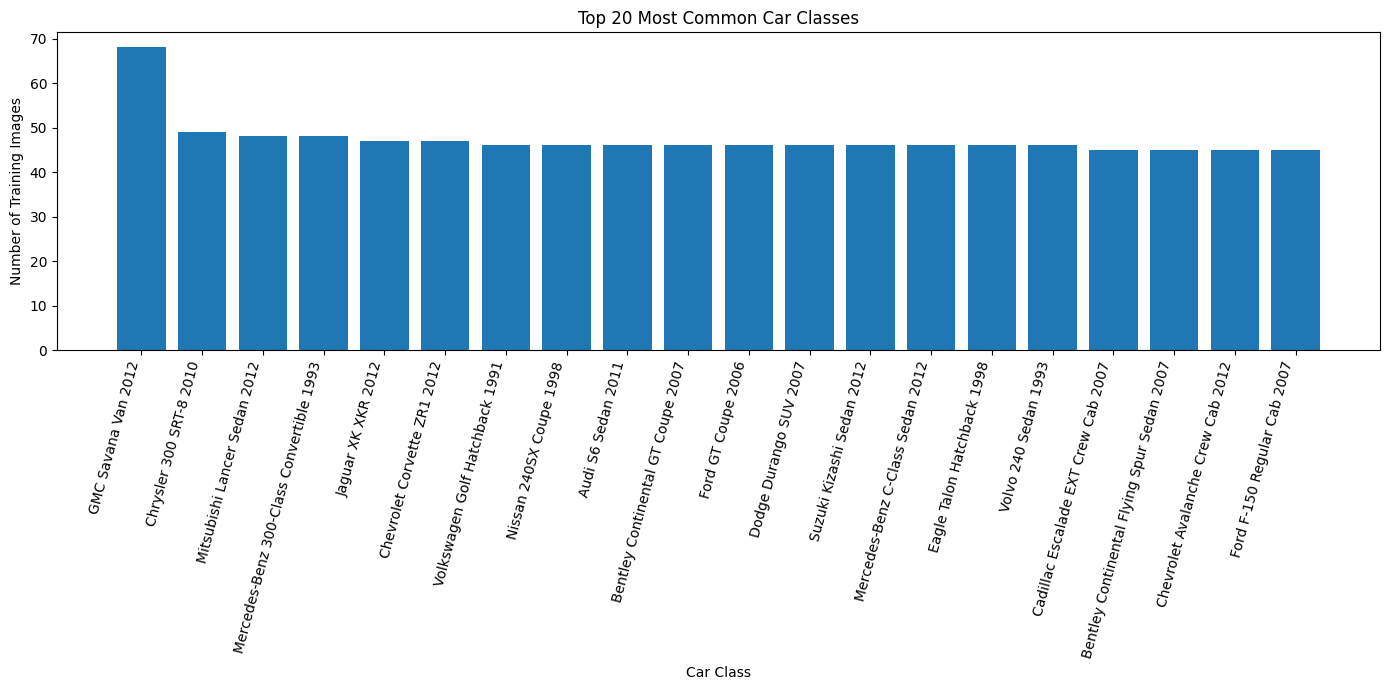

In [7]:
top_20 = class_distribution.head(20)

plt.figure(figsize=(14, 7))

plt.bar(
    range(len(top_20)),
    top_20["Number of Images"]
)

plt.xticks(
    range(len(top_20)),
    top_20["Class Name"],
    rotation=75,
    ha="right"
)

plt.xlabel("Car Class")
plt.ylabel("Number of Training Images")
plt.title("Top 20 Most Common Car Classes")

plt.tight_layout()
plt.show()

In [8]:
# 80% training / 20% validation
split = train_data.train_test_split(
    test_size=0.20,
    seed=42,
    stratify_by_column="label"
)

train_data = split["train"]
val_data = split["test"]

print("Training images  :", len(train_data))
print("Validation images:", len(val_data))
print("Test images      :", len(test_data))

Training images  : 6514
Validation images: 1629
Test images      : 8040



## **5. Data Preprocessing and Augmentation**

Image preprocessing is applied to make the input images compatible with EfficientNet-B0 and the pretrained ImageNet weights.

### **Training Preprocessing and Augmentation**

The following transformations are applied to the training images:

- **Random Resized Crop (224 × 224):** creates variations in image scale and position.
- **Random Horizontal Flip:** allows the model to learn from cars facing different directions.
- **Random Rotation:** introduces small orientation variations.
- **Color Jitter:** introduces variations in brightness, contrast, saturation, and color.
- **Tensor Conversion:** converts images into PyTorch tensors.
- **ImageNet Normalization:** normalizes the images using the mean and standard deviation used during ImageNet pretraining.

Data augmentation is applied only to the training set. It increases the diversity of the training images and can help reduce overfitting.

### **Validation and Test Preprocessing**

Random augmentation is not applied to validation or test images.

Instead, the images are resized, center-cropped to 224 × 224 pixels, converted to tensors, and normalized using the ImageNet normalization values.

Using deterministic preprocessing for validation and testing ensures that model performance is measured consistently.

In [9]:
# ImageNet normalization for pretrained EfficientNet-B0
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


# Training preprocessing + augmentation
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        224,
        scale=(0.7, 1.0),
        ratio=(0.8, 1.2)
    ),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(10),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.15,
        hue=0.05
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

eval_transform = transforms.Compose([
    transforms.Resize(256),

    transforms.CenterCrop(224),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

# Test preprocessing and No augmentation
test_transform = transforms.Compose([
    transforms.Resize(256),

    transforms.CenterCrop(224),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

In [10]:
def train_transform_function(examples):
    images = [
        train_transform(image.convert("RGB"))
        for image in examples["image"]
    ]

    return {
        "pixel_values": images,
        "labels": examples["label"]
    }

def eval_transform_function(examples):

    images = [
        eval_transform(image.convert("RGB"))
        for image in examples["image"]
    ]

    return {
        "pixel_values": images,
        "labels": examples["label"]
    }

def test_transform_function(examples):
    images = [
        test_transform(image.convert("RGB"))
        for image in examples["image"]
    ]

    return {
        "pixel_values": images,
        "labels": examples["label"]
    }


#train_dataset = train_data.with_transform(train_transform_function)

#test_dataset = test_data.with_transform(test_transform_function)

train_dataset = train_data.with_transform(
    train_transform_function
)

val_dataset = val_data.with_transform(
    eval_transform_function
)

test_dataset = test_data.with_transform(
    eval_transform_function
)

## **6. Data Loading**

PyTorch DataLoaders are used to efficiently provide batches of images and labels to the model.

The training DataLoader shuffles the images during every epoch to prevent the model from learning the order of the dataset.

The validation and test DataLoaders do not shuffle the data because these datasets are used only for evaluation.

A batch size of 32 is used, meaning that 32 images are processed together during each training iteration.

In [ ]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

print("Train batches     :", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches      :", len(test_loader))

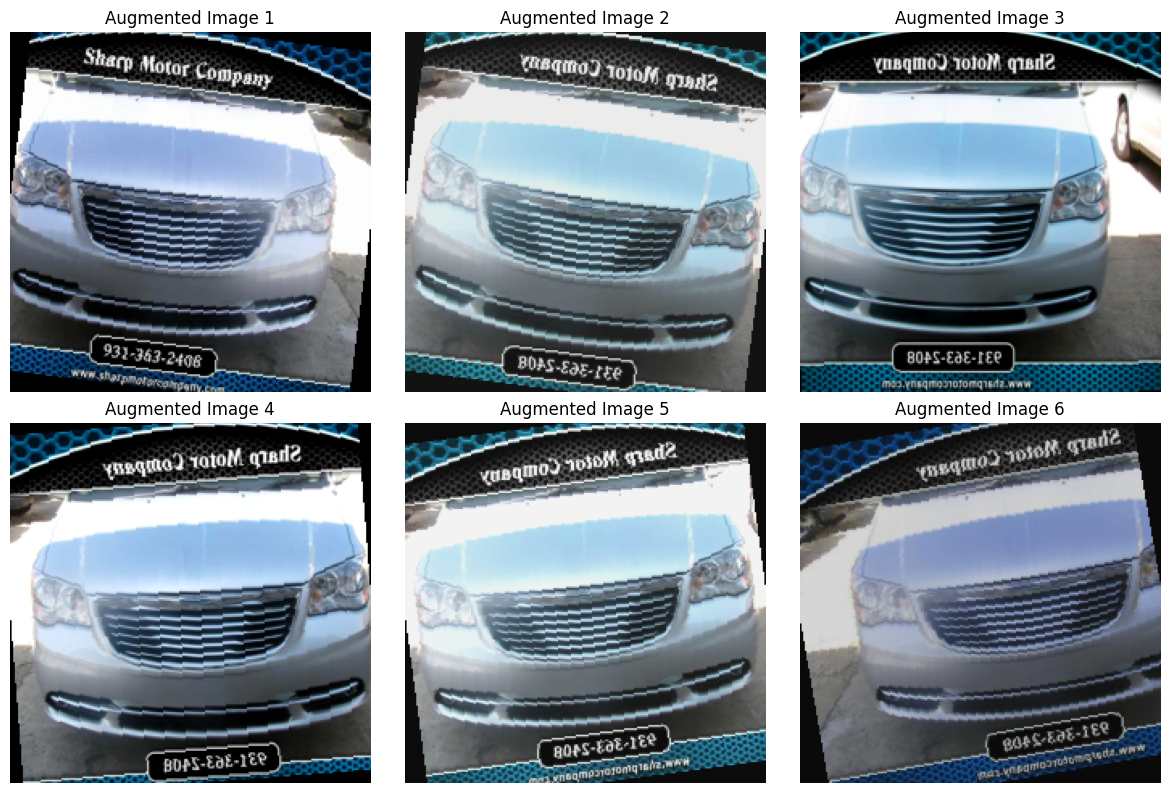

In [12]:
def denormalize(image):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)

    image = image * std + mean
    return torch.clamp(image, 0, 1)


original_image = train_data[0]["image"].convert("RGB")

plt.figure(figsize=(12, 8))

for i in range(6):
    augmented = train_transform(original_image)
    augmented = denormalize(augmented)
    augmented = augmented.permute(1, 2, 0).numpy()

    plt.subplot(2, 3, i + 1)
    plt.imshow(augmented)
    plt.axis("off")
    plt.title(f"Augmented Image {i+1}")

plt.tight_layout()
plt.show()

## **7. Model Selection – EfficientNet-B0**

EfficientNet-B0 is selected as the classification model for this project.

EfficientNet is a convolutional neural network architecture designed to achieve strong image classification performance while maintaining computational efficiency.

EfficientNet-B0 provides a suitable balance between model performance, computational requirements, and training time, making it appropriate for training in Google Colab.

### **Transfer Learning**

Instead of training the network from scratch, EfficientNet-B0 is initialized with weights pretrained on the ImageNet dataset.

The pretrained network has already learned useful general visual features such as:

- Edges
- Shapes
- Textures
- Object structures

These learned features can then be adapted to the Stanford Cars dataset through fine-tuning.

Transfer learning is particularly useful because the Stanford Cars training dataset is much smaller than datasets normally used to train deep convolutional networks from scratch.

### **Model Modification**

The original EfficientNet-B0 model is designed to classify images into 1,000 ImageNet categories.

The Stanford Cars dataset contains 196 classes. Therefore, the final classification layer of EfficientNet-B0 is replaced with a new fully connected layer containing 196 output neurons.

The modified classifier consists of:

1. A dropout layer with a probability of 0.2.
2. A fully connected layer receiving 1,280 input features.
3. 196 output values corresponding to the 196 car classes.

All layers of the pretrained model are fine-tuned so that the network can adapt its previously learned visual features to fine-grained car recognition.

In [ ]:
import torch
import torch.nn as nn
from torchvision.models import (
    efficientnet_b0,
    EfficientNet_B0_Weights
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

# Load fresh ImageNet pretrained model
weights = EfficientNet_B0_Weights.DEFAULT

model = efficientnet_b0(weights=weights)

# Number of Stanford Cars classes
num_classes = 196

# Replace classifier
num_features = model.classifier[1].in_features

model.classifier[1] = nn.Linear(
    num_features,
    num_classes
)

# Fine-tune ALL layers
for param in model.parameters():
    param.requires_grad = True

# Move model to GPU
model = model.to(device)

print(model.classifier)
print("Model device:", next(model.parameters()).device)

In [ ]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

In [ ]:
# Get one batch from the DataLoader
batch = next(iter(train_loader))

# Extract images and labels from the dictionary
images = batch["pixel_values"]
labels = batch["labels"]

# Move tensors to the selected device
images = images.to(device)
labels = labels.to(device)

# Forward pass through EfficientNet-B0
outputs = model(images)

print("Input shape :", images.shape)
print("Labels shape:", labels.shape)
print("Output shape:", outputs.shape)

## **now we start the training process**

## **8. Model Training**

The pretrained EfficientNet-B0 model is fine-tuned on the Stanford Cars training dataset.

### **Loss Function – Cross-Entropy Loss**

Cross-Entropy Loss is used because this project is a multi-class classification problem in which each image belongs to exactly one of 196 classes.

Label smoothing is also applied to reduce excessive model confidence and improve generalization.

### **Optimizer – AdamW**

AdamW is used to optimize the model parameters.

AdamW combines adaptive learning rates with weight decay regularization. A relatively small learning rate is used because the model already contains pretrained ImageNet features and is being fine-tuned rather than trained from scratch.

### **Learning Rate Scheduler**

Cosine Annealing is used to gradually decrease the learning rate throughout training.

A larger learning rate is useful during the earlier stages of fine-tuning, while smaller learning rates toward the end allow more precise adjustments to the model parameters.

### **Training Strategy**

During each training epoch:

1. A batch of training images is passed through EfficientNet-B0.
2. The model generates predictions for the 196 classes.
3. Cross-Entropy Loss measures the difference between predictions and true labels.
4. Backpropagation calculates the gradients.
5. AdamW updates the model parameters.
6. Training loss and accuracy are recorded.
7. The model is evaluated on the validation set.
8. Validation loss and accuracy are recorded.

The checkpoint with the highest validation accuracy is saved for final evaluation.

In [16]:

class_names = train_data.features["label"].names
num_classes = len(class_names)

print("Number of classes:", num_classes)


criterion = nn.CrossEntropyLoss(
    label_smoothing=0.1
)

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

num_epochs = 25

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=num_epochs
)


print("Training configuration ready.")

Number of classes: 196
Training configuration ready.


In [ ]:
for param in model.parameters():
    param.requires_grad = True

model = model.to(device)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Trainable parameters: {trainable_params:,}")

In [18]:
train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

best_val_accuracy = 0.0


for epoch in range(num_epochs):

    model.train()

    train_running_loss = 0.0
    train_correct = 0
    train_total = 0

    for batch in train_loader:

        images = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        optimizer.step()

        # Statistics
        train_running_loss += loss.item() * images.size(0)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        train_correct += (
            predictions == labels
        ).sum().item()

        train_total += labels.size(0)


    train_loss = (
        train_running_loss / train_total
    )

    train_accuracy = (
        100 * train_correct / train_total
    )


    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    # No gradients needed during validation
    with torch.no_grad():

        for batch in val_loader:

            images = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_running_loss += (
                loss.item() * images.size(0)
            )

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            val_correct += (
                predictions == labels
            ).sum().item()

            val_total += labels.size(0)


    val_loss = (
        val_running_loss / val_total
    )

    val_accuracy = (
        100 * val_correct / val_total
    )



    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)




    scheduler.step()

    current_lr = optimizer.param_groups[0]["lr"]



    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.2f}% | "
        f"LR: {current_lr:.6f}"
    )




    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),

            "train_loss": train_loss,
            "train_accuracy": train_accuracy,

            "val_loss": val_loss,
            "val_accuracy": val_accuracy

        }, "efficientnet_b0_stanford_cars_best.pth")

        print(
            f"→ Best validation model saved! "
            f"({val_accuracy:.2f}%)"
        )

Epoch [1/25] | Train Loss: 5.1896 | Train Acc: 2.09% | Val Loss: 4.9029 | Val Acc: 8.59% | LR: 0.000100
→ Best validation model saved! (8.59%)
Epoch [2/25] | Train Loss: 4.5319 | Train Acc: 15.60% | Val Loss: 4.0612 | Val Acc: 26.64% | LR: 0.000098
→ Best validation model saved! (26.64%)
Epoch [3/25] | Train Loss: 3.6674 | Train Acc: 35.20% | Val Loss: 3.2752 | Val Acc: 41.56% | LR: 0.000096
→ Best validation model saved! (41.56%)
Epoch [4/25] | Train Loss: 2.9416 | Train Acc: 52.72% | Val Loss: 2.7363 | Val Acc: 51.38% | LR: 0.000094
→ Best validation model saved! (51.38%)
Epoch [5/25] | Train Loss: 2.4290 | Train Acc: 66.52% | Val Loss: 2.3828 | Val Acc: 59.12% | LR: 0.000090
→ Best validation model saved! (59.12%)
Epoch [6/25] | Train Loss: 2.0521 | Train Acc: 75.58% | Val Loss: 2.1628 | Val Acc: 65.62% | LR: 0.000086
→ Best validation model saved! (65.62%)
Epoch [7/25] | Train Loss: 1.8140 | Train Acc: 80.87% | Val Loss: 2.0148 | Val Acc: 68.20% | LR: 0.000082
→ Best validation mod

KeyboardInterrupt: 

## **9. Training and Validation Analysis**

Training and validation loss and accuracy are monitored across the training epochs.

Training metrics measure how well the model learns the images used to update its parameters, while validation metrics measure how well the model generalizes to images that are not used for parameter updates.

Comparing these metrics is useful for identifying potential overfitting.

### **Signs of Good Learning**

A healthy training process generally shows:

- Decreasing training loss
- Increasing training accuracy
- Decreasing validation loss
- Increasing validation accuracy

### **Overfitting**

Overfitting can occur when training performance continues to improve while validation performance stops improving or becomes worse.

For this reason, the model with the highest validation accuracy is saved rather than automatically using the model from the final epoch.

### **Training Observations**

The training accuracy increased consistently during fine-tuning, demonstrating that EfficientNet-B0 successfully learned the fine-grained car classification task.

The validation accuracy also improved during training, although a gap developed between training and validation performance. This indicates that the model learned the training data more strongly than the validation data.

The best checkpoint was selected based on validation accuracy to avoid selecting a model purely based on training performance.

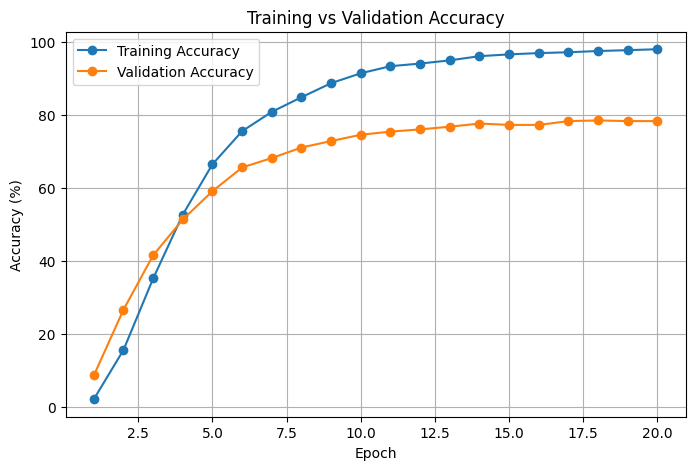

In [19]:
epochs = range(1, len(train_accuracies) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_accuracies,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs,
    val_accuracies,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()

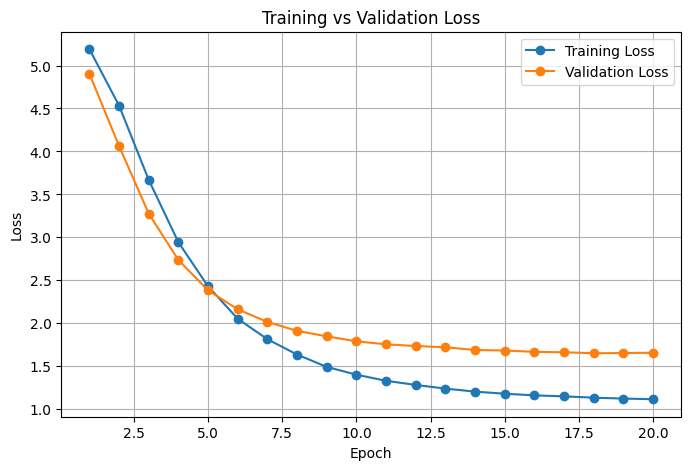

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_losses,
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    val_losses,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

## **10. Model Evaluation**

After training, the checkpoint with the highest validation accuracy is loaded and evaluated on the independent test dataset.

The test set was not used to update the model parameters or select the best checkpoint, allowing it to provide an independent measurement of the model's final generalization performance.

The following evaluation metrics are used:

### **Accuracy**

Accuracy measures the percentage of test images that are classified into the correct car class.

### **Precision**

Precision measures how often the model's predictions for a particular class are correct.

### **Recall**

Recall measures how successfully the model identifies the images that actually belong to each class.

### **F1-Score**

The F1-score combines precision and recall into a single metric, providing a balanced measurement of classification performance.

Macro averaging is used for precision, recall, and F1-score so that each of the 196 car classes contributes equally to the final metric.

### **Test Loss**

Test loss measures the model's classification error on unseen test images using the same Cross-Entropy Loss function used during training.

## **Final Test Results**

The best-performing EfficientNet-B0 checkpoint was obtained at **epoch 18** based on validation accuracy. This checkpoint was then evaluated on the independent test set.

| Metric | Result |
|---|---:|
| Best Epoch | 18 |
| Training Accuracy | 97.54% |
| Validation Accuracy | 78.51% |
| Validation Loss | 1.6516 |
| Test Accuracy | 78.52% |
| Test Loss | 1.6486 |
| Precision (Macro) | 79.33% |
| Recall (Macro) | 78.48% |
| F1-Score (Macro) | 78.50% |

### **Results Analysis**

The final model achieved a **test accuracy of 78.52%**, which is almost identical to the **validation accuracy of 78.51%**. The similarity between validation and test performance indicates that the validation set provided a reliable estimate of the model's performance on unseen data.

The model achieved a macro precision of **79.33%**, macro recall of **78.48%**, and macro F1-score of **78.50%**. Since macro averaging gives equal importance to each of the 196 car classes, these results indicate that the model achieved reasonably consistent classification performance across the different vehicle categories.

The training accuracy reached **97.54%**, which is considerably higher than the validation and test accuracies. This gap indicates that the model learned the training data more strongly than unseen data, suggesting some degree of overfitting. However, the close agreement between validation and test performance shows that the model's generalization performance is consistent.

The best model was selected at **epoch 18** based on validation accuracy rather than training accuracy, helping avoid selecting a later model simply because it performed better on the training data.

In [21]:
checkpoint = torch.load(
    "efficientnet_b0_stanford_cars_best.pth",
    map_location=device
)

model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(device)

print("Best model loaded!")
print("Best epoch:", checkpoint["epoch"])
print(f"Training accuracy: {checkpoint['train_accuracy']:.2f}%")
print(f"Validation accuracy: {checkpoint['val_accuracy']:.2f}%")
print(f"Validation loss: {checkpoint['val_loss']:.4f}")

Best model loaded!
Best epoch: 18
Training accuracy: 97.54%
Validation accuracy: 78.51%
Validation loss: 1.6516


In [ ]:
model.eval()

In [23]:
all_labels = []
all_predictions = []

test_running_loss = 0.0
test_correct = 0
test_total = 0

model.eval()

with torch.no_grad():

    for batch in test_loader:

        images = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        # Forward pass
        outputs = model(images)

        # Loss
        loss = criterion(outputs, labels)

        test_running_loss += loss.item() * images.size(0)

        # Predictions
        predictions = torch.argmax(outputs, dim=1)

        test_correct += (predictions == labels).sum().item()
        test_total += labels.size(0)

        # Save results for later metrics
        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())


test_loss = test_running_loss / test_total
test_accuracy = 100 * test_correct / test_total

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Loss: 1.6486
Test Accuracy: 78.52%


In [24]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

precision = precision_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

recall = recall_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

f1 = f1_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

print(f"Accuracy : {test_accuracy:.2f}%")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

Accuracy : 78.52%
Precision: 0.7933
Recall   : 0.7848
F1-score : 0.7850


## **11. Successful Predictions and Failure Cases**

To better understand model behavior, individual predictions from the test dataset are examined.

### **Successful Predictions**

Correct predictions demonstrate cases where EfficientNet-B0 successfully identifies the vehicle make, model, and year.

The predicted class, actual class, and model confidence are displayed for each example.

### **Failure Cases**

Incorrect predictions are also examined to understand the limitations of the model.

For each failure case, the actual class and predicted class are compared.

Because this is a fine-grained classification problem, some errors may occur between vehicles with very similar visual characteristics. Factors such as viewing angle, background, lighting, image quality, and similarities between different vehicle models can also contribute to classification errors.

Analyzing these failure cases helps identify possible directions for improving the model.

In [25]:
from sklearn.metrics import classification_report

class_names = train_data.features["label"].names

report = classification_report(
    all_labels,
    all_predictions,
    target_names=class_names,
    zero_division=0
)

print(report)

                                                        precision    recall  f1-score   support

                            AM General Hummer SUV 2000       0.82      0.93      0.87        44
                                   Acura RL Sedan 2012       0.69      0.62      0.66        32
                                   Acura TL Sedan 2012       0.71      0.93      0.81        43
                                  Acura TL Type-S 2008       0.88      0.86      0.87        42
                                  Acura TSX Sedan 2012       0.90      0.68      0.77        40
                             Acura Integra Type R 2001       0.80      0.91      0.85        44
                              Acura ZDX Hatchback 2012       0.82      0.79      0.81        39
              Aston Martin V8 Vantage Convertible 2012       0.71      0.64      0.67        45
                    Aston Martin V8 Vantage Coupe 2012       0.85      0.56      0.68        41
                  Aston Martin Virage C

In [28]:
# Copy matrix so we can remove correct predictions
cm_errors = cm.copy()

# Remove diagonal
np.fill_diagonal(cm_errors, 0)

# Find largest confusion pairs
flat_indices = np.argsort(cm_errors.ravel())[::-1]

print("Most Common Misclassifications:\n")

shown = 0

for index in flat_indices:

    actual, predicted = np.unravel_index(
        index,
        cm_errors.shape
    )

    count = cm_errors[actual, predicted]

    if count == 0:
        break

    print(
        f"{class_names[actual]}"
        f"\n   → predicted as: {class_names[predicted]}"
        f"\n   → {count} times\n"
    )

    shown += 1

    if shown == 10:
        break

Most Common Misclassifications:

BMW 6 Series Convertible 2007
   → predicted as: BMW M6 Convertible 2010
   → 16 times

Audi TTS Coupe 2012
   → predicted as: Audi TT Hatchback 2011
   → 15 times

Audi S5 Coupe 2012
   → predicted as: Audi A5 Coupe 2012
   → 12 times

Dodge Caliber Wagon 2012
   → predicted as: Dodge Caliber Wagon 2007
   → 12 times

Chevrolet Express Van 2007
   → predicted as: Chevrolet Express Cargo Van 2007
   → 12 times

Dodge Sprinter Cargo Van 2009
   → predicted as: Mercedes-Benz Sprinter Van 2012
   → 11 times

Ferrari 458 Italia Coupe 2012
   → predicted as: Ferrari 458 Italia Convertible 2012
   → 11 times

Chevrolet Tahoe Hybrid SUV 2012
   → predicted as: Chevrolet Avalanche Crew Cab 2012
   → 10 times

Chevrolet Express Van 2007
   → predicted as: GMC Savana Van 2012
   → 10 times

Chevrolet Silverado 1500 Extended Cab 2012
   → predicted as: Chevrolet Silverado 1500 Hybrid Crew Cab 2012
   → 9 times



In [29]:
import torch.nn.functional as F
import matplotlib.pyplot as plt


def denormalize(image):

    mean = torch.tensor(
        IMAGENET_MEAN
    ).view(3, 1, 1)

    std = torch.tensor(
        IMAGENET_STD
    ).view(3, 1, 1)

    image = image.cpu() * std + mean

    return torch.clamp(
        image,
        0,
        1
    )

In [30]:
model.eval()

correct_examples = []

with torch.no_grad():

    for batch in test_loader:

        images = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(images)

        probabilities = F.softmax(
            outputs,
            dim=1
        )

        confidence, predictions = torch.max(
            probabilities,
            dim=1
        )

        for i in range(len(labels)):

            if predictions[i] == labels[i]:

                correct_examples.append((
                    images[i],
                    labels[i].item(),
                    predictions[i].item(),
                    confidence[i].item()
                ))

            if len(correct_examples) >= 6:
                break

        if len(correct_examples) >= 6:
            break

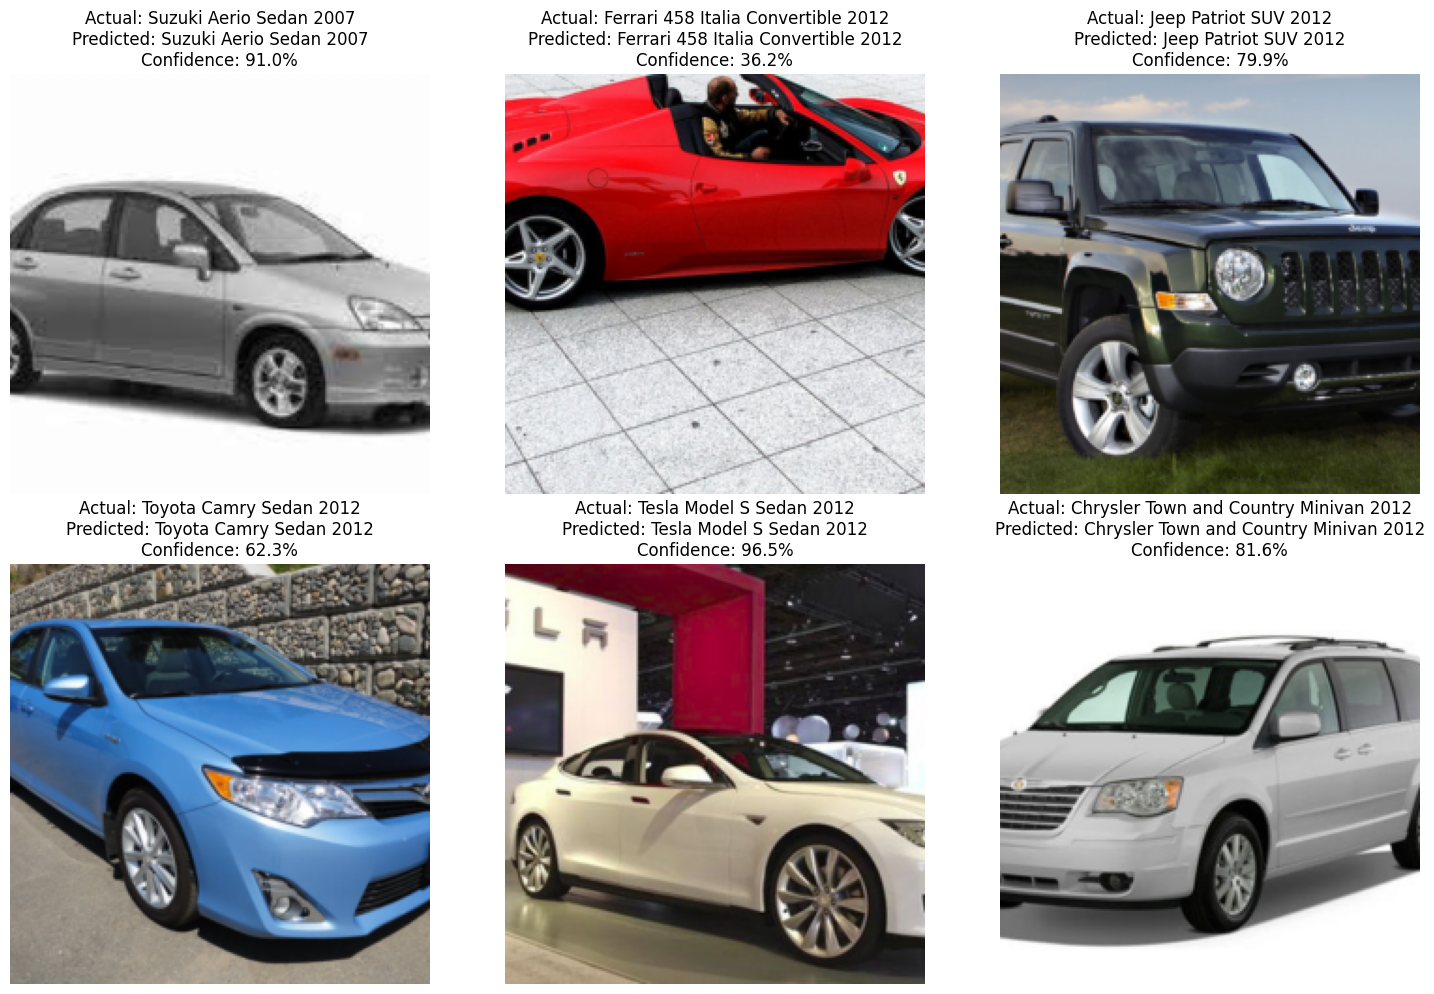

In [31]:
plt.figure(figsize=(15, 10))

for i, (image, actual, predicted, confidence) in enumerate(correct_examples):

    image = denormalize(image)
    image = image.permute(1, 2, 0).numpy()

    plt.subplot(2, 3, i + 1)

    plt.imshow(image)
    plt.axis("off")

    plt.title(
        f"Actual: {class_names[actual]}\n"
        f"Predicted: {class_names[predicted]}\n"
        f"Confidence: {confidence*100:.1f}%"
    )

plt.tight_layout()
plt.show()

In [32]:
model.eval()

wrong_examples = []

with torch.no_grad():

    for batch in test_loader:

        images = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(images)

        probabilities = F.softmax(
            outputs,
            dim=1
        )

        confidence, predictions = torch.max(
            probabilities,
            dim=1
        )

        for i in range(len(labels)):

            if predictions[i] != labels[i]:

                wrong_examples.append((
                    images[i],
                    labels[i].item(),
                    predictions[i].item(),
                    confidence[i].item()
                ))

            if len(wrong_examples) >= 6:
                break

        if len(wrong_examples) >= 6:
            break

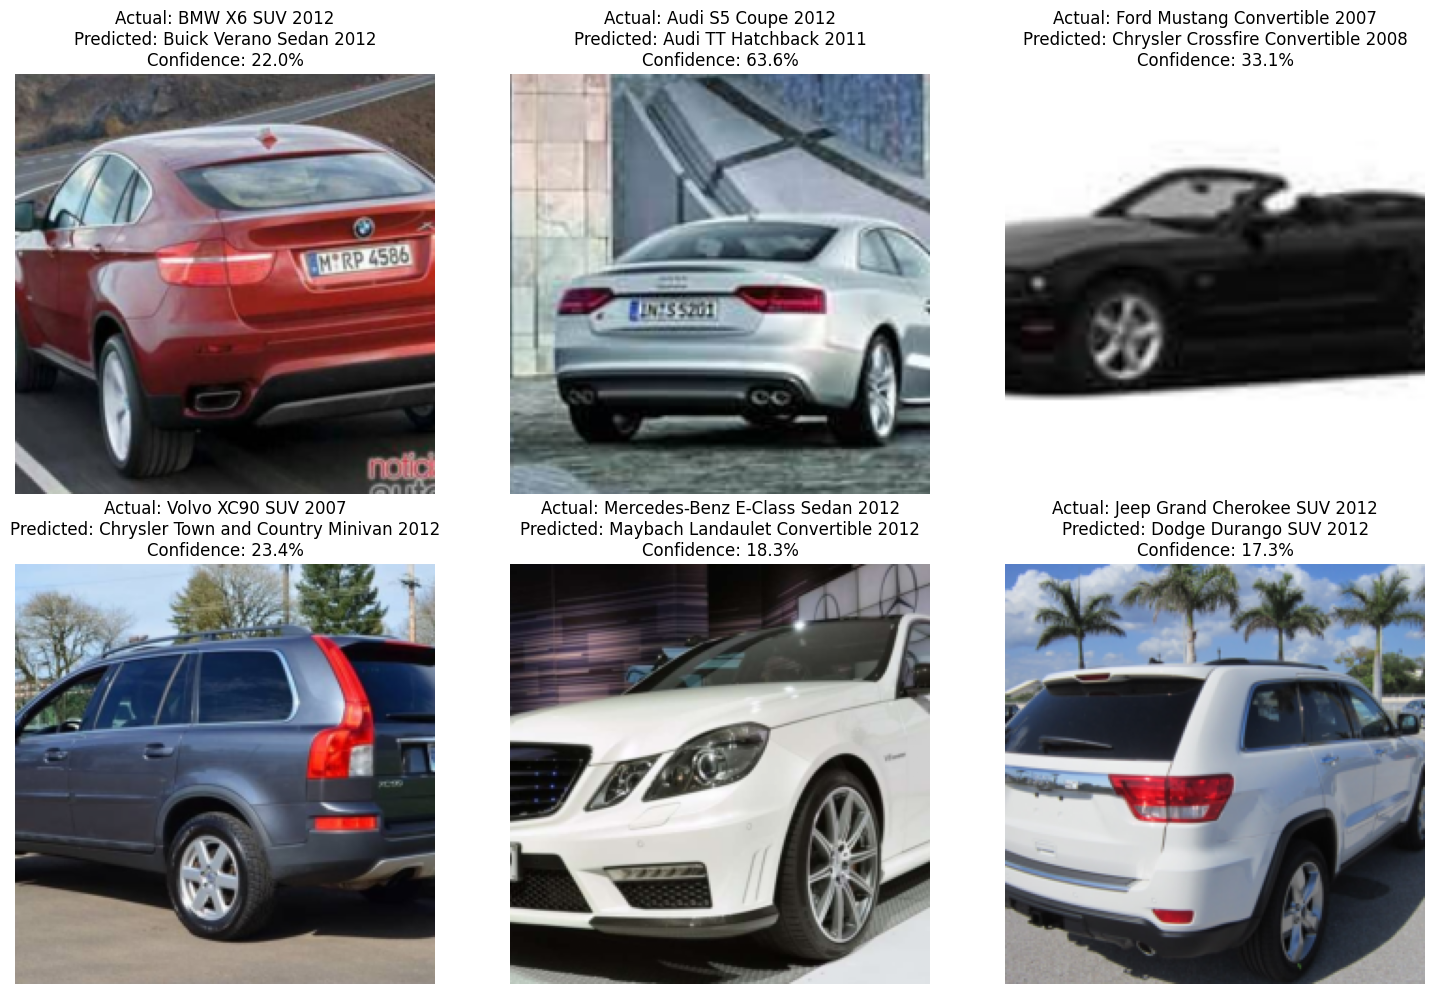

In [33]:
plt.figure(figsize=(15, 10))

for i, (image, actual, predicted, confidence) in enumerate(wrong_examples):

    image = denormalize(image)
    image = image.permute(1, 2, 0).numpy()

    plt.subplot(2, 3, i + 1)

    plt.imshow(image)
    plt.axis("off")

    plt.title(
        f"Actual: {class_names[actual]}\n"
        f"Predicted: {class_names[predicted]}\n"
        f"Confidence: {confidence*100:.1f}%"
    )

plt.tight_layout()
plt.show()

## 12. Future Improvements

Although EfficientNet-B0 achieves strong classification performance, several improvements could be investigated:

1. **Higher Image Resolution**  
   Using larger input images may help the model capture small visual differences between similar vehicle models.

2. **Improved Data Augmentation**  
   Additional augmentation strategies could improve robustness to different lighting conditions, backgrounds, scales, and camera angles.

3. **Hyperparameter Tuning**  
   The learning rate, weight decay, batch size, and scheduler parameters could be further optimized.

4. **Alternative EfficientNet Variants**  
   Larger models such as EfficientNet-B1, B2, or B3 could potentially capture more detailed visual features.

5. **More Advanced Architectures**  
   Modern architectures such as ConvNeXt or Vision Transformers could be compared with EfficientNet-B0.

6. **Fine-Tuning Strategy**  
   Different learning rates could be used for the pretrained feature extractor and the newly added classifier.

7. **More Training Data**  
   Additional car images captured under different real-world conditions could improve generalization.

## **13. Deployment and Real-World Application**

The trained model could be integrated into a simple vehicle recognition application.

A user could upload an image of a car, after which the system would:

1. Receive the input image.
2. Apply the required preprocessing.
3. Pass the image through the trained EfficientNet-B0 model.
4. Calculate class probabilities.
5. Return the predicted car make, model, and year.
6. Display the prediction confidence.

A possible application workflow is:

**Car Image → Image Preprocessing → EfficientNet-B0 → Class Probabilities → Predicted Make/Model/Year**

The system could potentially be deployed as a web application or integrated into intelligent transportation and vehicle management systems.

For more efficient deployment, the trained PyTorch model could also be converted to a format such as ONNX or optimized using model quantization.

## **14. Technologies Used**

The following technologies and libraries were used:

- Python
- Google Colab
- PyTorch
- TorchVision
- Hugging Face Datasets
- EfficientNet-B0
- NumPy
- Pandas
- Matplotlib
- Scikit-learn

GPU acceleration was used in Google Colab to speed up model training and evaluation.

## **15. Conclusion**

This project developed a fine-grained car classification system using the Stanford Cars dataset and a pretrained EfficientNet-B0 model.

Transfer learning was used to take advantage of visual features previously learned from ImageNet, while fine-tuning adapted the network to distinguish between 196 specific car classes.

The project implemented a complete computer vision pipeline including dataset exploration, preprocessing, data augmentation, transfer learning, model training, validation, test evaluation, and error analysis.

Training and validation metrics were monitored to analyze model learning and generalization. The final model was selected based on validation performance and evaluated on an independent test set using accuracy, precision, recall, F1-score, Top-5 accuracy, confusion analysis, and individual prediction examples.

The results demonstrate the effectiveness of transfer learning for fine-grained vehicle recognition while also highlighting the difficulty of distinguishing between visually similar car models.